In [2]:
# Install missing frameworks
!pip install -q lightning flax onnx onnxruntime tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 54.0 MB/s eta 0:00:00


In [3]:
# Setup Models
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import tensorflow as tf
from tensorflow.keras import layers, models
import jax
import jax.numpy as jnp
from flax import linen as flax_nn
import onnxruntime as ort

print("PyTorch Version:", torch.__version__)
print("TensorFlow Version:", tf.__version__)
print("JAX Version:", jax.__version__)

PyTorch Version: 2.11.0+cu128
TensorFlow Version: 2.20.0
JAX Version: 0.7.2


In [4]:
# --- 1. PyTorch Model ---
class PyTorchEMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 47)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_pt = PyTorchEMNIST().eval()

In [5]:
# --- 2. PyTorch Lightning Model ---
class LitEMNIST(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = PyTorchEMNIST()

    def forward(self, x):
        return self.model(x)

model_lit = LitEMNIST().eval()

In [6]:
# --- 3. TensorFlow / Keras Model ---
model_tf = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(47)
])

In [7]:
# --- 4. JAX / Flax Model ---
class FlaxEMNIST(flax_nn.Module):
    @flax_nn.compact
    def __call__(self, x):
        x = flax_nn.Conv(features=32, kernel_size=(3, 3))(x)
        x = flax_nn.relu(x)
        x = flax_nn.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = flax_nn.Conv(features=64, kernel_size=(3, 3))(x)
        x = flax_nn.relu(x)
        x = flax_nn.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = x.reshape((x.shape[0], -1))
        x = flax_nn.Dense(features=128)(x)
        x = flax_nn.relu(x)
        x = flax_nn.Dense(features=47)(x)
        return x

flax_model = FlaxEMNIST()
rng = jax.random.PRNGKey(42)
dummy_jax_input = jnp.ones((1, 28, 28, 1))
flax_params = flax_model.init(rng, dummy_jax_input)

# JIT-compile inference function for high performance
@jax.jit
def jax_predict(params, x):
    return flax_model.apply(params, x)

In [8]:
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 16.7 MB/s eta 0:00:00


In [9]:
# --- 5. ONNX Runtime (Export from PyTorch) ---
dummy_onnx_input = torch.randn(1, 1, 28, 28)
onnx_path = "emnist_model.onnx"

torch.onnx.export(
    model_pt,
    dummy_onnx_input,
    onnx_path,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    dynamo=False  # Skips onnxscript dependency
)

ort_session = ort.InferenceSession(onnx_path)
ort_input_name = ort_session.get_inputs()[0].name

/tmp/ipykernel_1196/3480660889.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [10]:
# Benchmark Runner
def benchmark_inference(predict_fn, sample_input, num_warmup=50, num_runs=500):
    # Warmup phase
    for _ in range(num_warmup):
        _ = predict_fn(sample_input)

    # Timed benchmark phase
    start_time = time.perf_counter()
    for _ in range(num_runs):
        _ = predict_fn(sample_input)
    end_time = time.perf_counter()

    avg_latency_ms = ((end_time - start_time) / num_runs) * 1000.0
    return avg_latency_ms

In [11]:
# Cell 4: Run Tests & Build Pandas Comparison Table
results = []
batch_sizes = [1, 64]

for b in batch_sizes:
    # Prepare inputs according to framework shape conventions
    pt_input = torch.randn(b, 1, 28, 28)           # (B, C, H, W)
    tf_input = tf.random.normal((b, 28, 28, 1))     # (B, H, W, C)
    jax_input = jnp.ones((b, 28, 28, 1))           # (B, H, W, C)
    ort_input = np.random.randn(b, 1, 28, 28).astype(np.float32)

    # 1. PyTorch
    with torch.no_grad():
        t_pt = benchmark_inference(lambda x: model_pt(x), pt_input)

    # 2. PyTorch Lightning
    with torch.no_grad():
        t_lit = benchmark_inference(lambda x: model_lit(x), pt_input)

    # 3. TensorFlow / Keras
    t_tf = benchmark_inference(lambda x: model_tf(x, training=False), tf_input)

    # 4. JAX / Flax (block until computation is fully finished on device)
    t_jax = benchmark_inference(lambda x: jax_predict(flax_params, x).block_until_ready(), jax_input)

    # 5. ONNX Runtime
    t_ort = benchmark_inference(lambda x: ort_session.run(None, {ort_input_name: x}), ort_input)

    results.append({
        "Batch Size": b,
        "PyTorch (ms)": round(t_pt, 3),
        "PyTorch Lightning (ms)": round(t_lit, 3),
        "TensorFlow/Keras (ms)": round(t_tf, 3),
        "JAX / Flax (JIT) (ms)": round(t_jax, 3),
        "ONNX Runtime (ms)": round(t_ort, 3)
    })

# Convert to clean Comparison DataFrame
df_raw = pd.DataFrame(results)

# Transpose for easier reading by Framework
summary = []
frameworks = [
    ("PyTorch", "PyTorch (ms)"),
    ("PyTorch Lightning", "PyTorch Lightning (ms)"),
    ("TensorFlow / Keras", "TensorFlow/Keras (ms)"),
    ("JAX / Flax (JIT)", "JAX / Flax (JIT) (ms)"),
    ("ONNX Runtime", "ONNX Runtime (ms)")
]

for name, col in frameworks:
    lat_b1 = df_raw.loc[df_raw["Batch Size"] == 1, col].values[0]
    lat_b64 = df_raw.loc[df_raw["Batch Size"] == 64, col].values[0]
    throughput_b64 = int((64 / (lat_b64 / 1000.0)))

    summary.append({
        "Framework": name,
        "Latency B=1 (ms)": f"{lat_b1:.3f} ms",
        "Latency B=64 (ms)": f"{lat_b64:.3f} ms",
        "Throughput (img/sec)": f"{throughput_b64:,} items/s",
        "Primary Advantage": {
            "PyTorch": "Ecosystem & dynamic graph",
            "PyTorch Lightning": "Clean production training code",
            "TensorFlow / Keras": "Beginner-friendly API",
            "JAX / Flax (JIT)": "XLA-compiled functional speed",
            "ONNX Runtime": "Graph-optimized CPU inference"
        }[name]
    })

df_summary = pd.DataFrame(summary).sort_values(by="Latency B=1 (ms)")

print("=" * 70)
print("          MNIST INFERENCE BENCHMARK COMPARISON TABLE")
print("=" * 70)
display(df_summary)

          MNIST INFERENCE BENCHMARK COMPARISON TABLE


,Framework,Latency B=1 (ms),Latency B=64 (ms),Throughput (img/sec),Primary Advantage
4,ONNX Runtime,0.102 ms,3.657 ms,"17,500 items/s",Graph-optimized CPU inference
3,JAX / Flax (JIT),0.309 ms,0.492 ms,"130,081 items/s",XLA-compiled functional speed
0,PyTorch,1.913 ms,20.806 ms,"3,076 items/s",Ecosystem & dynamic graph
1,PyTorch Lightning,2.115 ms,20.267 ms,"3,157 items/s",Clean production training code
2,TensorFlow / Keras,21.197 ms,7.015 ms,"9,123 items/s",Beginner-friendly API


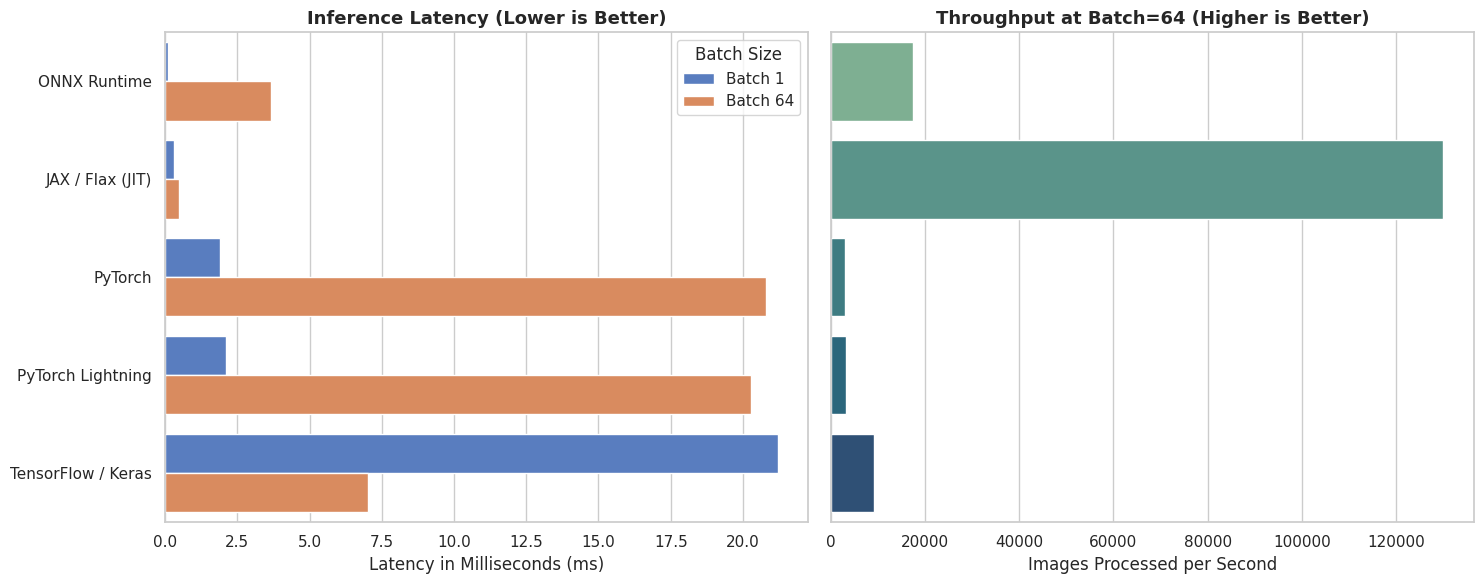

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Clean numerical data from df_summary for plotting
plot_df = df_summary.copy()
plot_df["Latency B=1 (ms)"] = plot_df["Latency B=1 (ms)"].str.replace(" ms", "").astype(float)
plot_df["Latency B=64 (ms)"] = plot_df["Latency B=64 (ms)"].str.replace(" ms", "").astype(float)
plot_df["Throughput (img/sec)"] = plot_df["Throughput (img/sec)"].str.replace(" items/s", "").str.replace(",", "").astype(int)

# --- Plot 1: Latency Comparison (Lower is Better) ---
# Melt dataframe to plot both batch sizes side-by-side
df_melted = plot_df.melt(
    id_vars="Framework",
    value_vars=["Latency B=1 (ms)", "Latency B=64 (ms)"],
    var_name="Batch Size",
    value_name="Latency (ms)"
)
df_melted["Batch Size"] = df_melted["Batch Size"].map({"Latency B=1 (ms)": "Batch 1", "Latency B=64 (ms)": "Batch 64"})

sns.barplot(data=df_melted, x="Latency (ms)", y="Framework", hue="Batch Size", ax=axes[0], palette="muted")
axes[0].set_title("Inference Latency (Lower is Better)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Latency in Milliseconds (ms)")
axes[0].set_ylabel("")

# --- Plot 2: Throughput Comparison (Higher is Better) ---
sns.barplot(data=plot_df, x="Throughput (img/sec)", y="Framework", ax=axes[1], palette="crest", hue="Framework", legend=False)
axes[1].set_title("Throughput at Batch=64 (Higher is Better)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Images Processed per Second")
axes[1].set_ylabel("")
axes[1].set_yticklabels([]) # Hide labels on the right plot since they share frameworks

# Adjust spacing and show the visualization
plt.tight_layout()
plt.show()
